In [17]:
# !pip install mediapipe-silicon opencv-python pandas scikit-learn

## 1. Import Dependencies

In [18]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles
mp_holistic = mp.solutions.holistic
mp_pose = mp.solutions.pose

## 2. Capture Landmarks and Export CSV

#### 2_1. Import Dependencies

In [19]:
import csv
import os
import numpy as np
import matplotlib.pyplot as plt

In [20]:
landmarks = ['class']
for val in range(1, 33+1):
    landmarks += [f'x{val}', f'y{val}', f'z{val}', f'v{val}']

In [21]:
with open('HipHig_coords.csv', mode='w', newline='') as f:
    csv_writer = csv.writer(f, delimiter=',', quotechar='"', quoting=csv.QUOTE_MINIMAL)
    csv_writer.writerow(landmarks)

In [22]:
def export_landmark(results, action):
    try:
        keypoints = [action] + [coord for res in results.pose_landmarks.landmark for coord in [res.x, res.y, res.z, res.visibility]]
        
        with open('HipHig_coords.csv', mode='a', newline='') as f:
            csv_writer = csv.writer(f, delimiter=',', quotechar='"', quoting=csv.QUOTE_MINIMAL)
            csv_writer.writerow(keypoints)
    except Exception as e:
        pass

### HipHig Labeling

In [37]:
# Hiphig Correct Posture
cap = cv2.VideoCapture(r'C:\Users\mukar\Desktop\FitX-Ai based Physiotherapy & Rehabilitation system\labeling\Dataset\HipHig\correctPosture\5.mov')

with mp_pose.Pose(model_complexity=2, smooth_landmarks=True, enable_segmentation=True, min_detection_confidence=0.7, min_tracking_confidence=0.7) as pose:

    while cap.isOpened():
        ret, image = cap.read()
        
        if not ret:
            break
        
        width = 480
        height = 854
        image = cv2.resize(image, (width, height))
            
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image.flags.writeable = False

        results = pose.process(image)

        image.flags.writeable = True
        image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
        
        mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_pose.POSE_CONNECTIONS,
                                 mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4),
                                 mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2))
        k = cv2.waitKey(1)
        if k == ord('u'): 
            export_landmark(results, 'HH_correct_up') 
            print('Correct up')
        if k == ord('d'): # d: down
            export_landmark(results, 'HH_correct_down') 
            print('Correct down')
            
        cv2.imshow('Raw Webcam Feed', image)
        
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break
            
cap.release()
cv2.destroyAllWindows()
cv2.waitKey(1)

Correct down
Correct down
Correct down
Correct down
Correct down
Correct down
Correct down
Correct down
Correct down
Correct down
Correct down
Correct down
Correct down
Correct down
Correct down
Correct down
Correct down
Correct down
Correct down
Correct up
Correct up
Correct up
Correct up
Correct up
Correct up
Correct up
Correct up
Correct up
Correct up
Correct up
Correct up
Correct up
Correct up
Correct up
Correct up
Correct up
Correct up
Correct up
Correct up
Correct up
Correct up
Correct up
Correct up


-1

In [35]:
# Incorrect Posture 1 - Excessive Knee
cap = cv2.VideoCapture(r'C:\Users\mukar\Desktop\FitX-Ai based Physiotherapy & Rehabilitation system\labeling\Dataset\HipHig\excessiveKneeFlexion\4.mov')

with mp_pose.Pose(model_complexity=2, smooth_landmarks=True, enable_segmentation=True, min_detection_confidence=0.7, min_tracking_confidence=0.7) as pose:

    while cap.isOpened():
        ret, image = cap.read()
        
        if not ret:
            break
            
        width = 480
        height = 854
        image = cv2.resize(image, (width, height))
            
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image.flags.writeable = False
        
        results = pose.process(image)
        
        image.flags.writeable = True
        image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
        
        mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_pose.POSE_CONNECTIONS,
                                 mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4),
                                 mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2))
        k = cv2.waitKey(1)
        if k == ord('u'): # u: up
            export_landmark(results, 'excessive_Knee_up') 
            print('excessiveKnee up')
        if k == ord('d'): # d: down
            export_landmark(results, 'excessive_Knee_down') 
            print('excessiveKnee down')
        
        cv2.imshow('Raw Webcam Feed', image)
        
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break
            
cap.release()
cv2.destroyAllWindows()
cv2.waitKey(1)

excessiveKnee down
excessiveKnee down
excessiveKnee down
excessiveKnee down
excessiveKnee down
excessiveKnee down
excessiveKnee down
excessiveKnee down
excessiveKnee down
excessiveKnee down
excessiveKnee down
excessiveKnee down
excessiveKnee up
excessiveKnee up
excessiveKnee up
excessiveKnee up
excessiveKnee up
excessiveKnee up
excessiveKnee up
excessiveKnee up
excessiveKnee up
excessiveKnee up
excessiveKnee up
excessiveKnee up
excessiveKnee up


-1

In [36]:
# Incorrect Posture 2 - Spine Missallignment
cap = cv2.VideoCapture(r'C:\Users\mukar\Desktop\FitX-Ai based Physiotherapy & Rehabilitation system\labeling\Dataset\HipHig\spineMisalignment\4.mov')

with mp_pose.Pose(model_complexity=2, smooth_landmarks=True, enable_segmentation=True, min_detection_confidence=0.7, min_tracking_confidence=0.7) as pose:

    while cap.isOpened():
        ret, image = cap.read()
        
        if not ret:
            break
            
        width = 480
        height = 854
        image = cv2.resize(image, (width, height))
        
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image.flags.writeable = False
        
        results = pose.process(image)
        
        image.flags.writeable = True
        image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
        
        mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_pose.POSE_CONNECTIONS,
                                 mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4),
                                 mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2))
        k = cv2.waitKey(1)
        if k == ord('u'): # u: up
            export_landmark(results, 'spine_Misalignment_up') 
            print('spineMisalignment up')
        if k == ord('d'): # d: down
            export_landmark(results, 'spine_Misalignment_down') 
            print('spineMisalignment down')
        
        cv2.imshow('Raw Webcam Feed', image)
        
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break
            
cap.release()
cv2.destroyAllWindows()
cv2.waitKey(1)

spineMisalignment down
spineMisalignment down
spineMisalignment down
spineMisalignment down
spineMisalignment down
spineMisalignment down
spineMisalignment down
spineMisalignment down
spineMisalignment down
spineMisalignment down
spineMisalignment down
spineMisalignment down
spineMisalignment down
spineMisalignment down
spineMisalignment down
spineMisalignment up
spineMisalignment up
spineMisalignment up
spineMisalignment up
spineMisalignment up
spineMisalignment up
spineMisalignment up
spineMisalignment up
spineMisalignment up
spineMisalignment up
spineMisalignment up
spineMisalignment up
spineMisalignment up
spineMisalignment up
spineMisalignment up
spineMisalignment up
spineMisalignment up
spineMisalignment up


-1

# Visualizing labeled results

In [41]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [42]:
HipHig = pd.read_csv('./HipHig_coords.csv')
HipHig.head()

,class,x1,y1,z1,v1,x2,y2,z2,v2,x3,...,z31,v31,x32,y32,z32,v32,x33,y33,z33,v33
0,HH_correct_up,0.495460,0.232346,-0.012427,0.999214,0.499850,0.218067,-0.029999,0.999084,0.501275,...,0.121504,0.301898,0.501841,0.802924,-0.145919,0.896996,0.504547,0.779274,0.066488,0.368361
1,HH_correct_down,0.481014,0.248532,-0.018214,0.999297,0.484057,0.233193,-0.037008,0.999166,0.485566,...,0.126444,0.295943,0.502574,0.804116,-0.137061,0.886306,0.504914,0.784212,0.067742,0.363697
2,HH_correct_down,0.474186,0.265293,-0.017055,0.999627,0.476055,0.250516,-0.036390,0.999558,0.477248,...,0.114685,0.371898,0.501653,0.804908,-0.150901,0.917327,0.504508,0.783045,0.068888,0.420405
3,HH_correct_down,0.467863,0.279250,-0.019977,0.999772,0.469359,0.264307,-0.040694,0.999731,0.470442,...,0.131153,0.339455,0.500470,0.804877,-0.147891,0.909351,0.505021,0.779783,0.084932,0.361021
4,HH_correct_down,0.462199,0.294758,-0.013296,0.999860,0.463218,0.280154,-0.034047,0.999835,0.464392,...,0.168644,0.261061,0.496677,0.799916,-0.187489,0.891596,0.504086,0.775404,0.128781,0.261153


C:\Users\mukar\AppData\Local\Temp\ipykernel_23508\3030174800.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=HipHig['class'], palette='Set2')


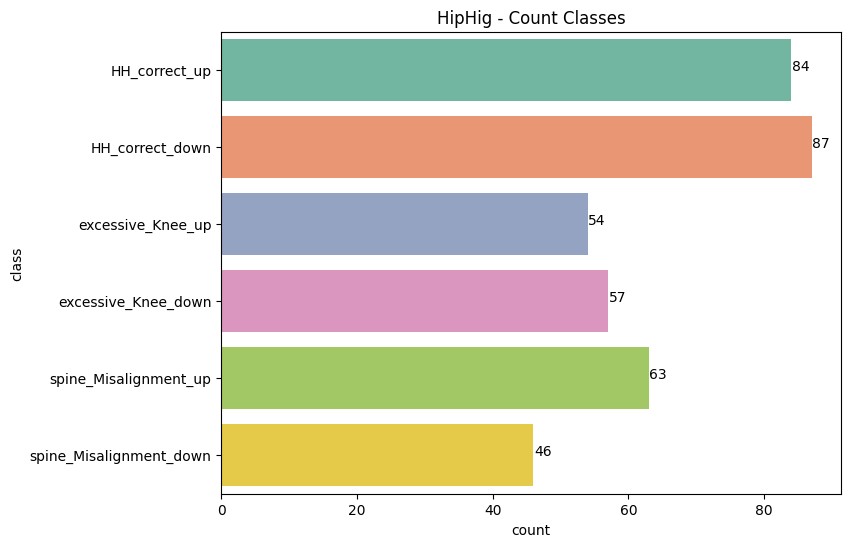

counts: 391


In [43]:
plt.figure(figsize=(8, 6))
plt.title('HipHig - Count Classes')

ax = sns.countplot(y=HipHig['class'], palette='Set2')

for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}', (p.get_x() + p.get_width() + 0.1, p.get_y() + 0.4))

plt.show()
print(f'counts: {len(HipHig["class"])}')